<a href="https://colab.research.google.com/github/yangkeyin/Resume-Algorithms-Lab/blob/main/EXP_002_%E4%B8%BA%E4%BB%80%E4%B9%88%E9%95%BF%E6%96%87%E6%9C%AC%E8%A6%81%E8%B0%83%E5%A4%A7_Base%EF%BC%8C%E9%A2%91%E7%8E%87%E5%9B%BE%E8%A7%A3%E9%87%8A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


在RoPE中，每一维度的旋转频率是不同的，第i组维度的角度计算公式是$$\theta_i = \frac{1}{\text{Base}^{2i/d}}$$

原因：
1. 旋转即位置：旋转角度即位置，角度转的越快，能标记的唯一位置就越短
2. base是调速器：调大base本质上是把旋转的速度降下来，这样即使在长文本中，也可能能标记唯一位置
3. 腾出空间：旋转变慢了，模型就可以在有限的角度空间里（0-2pi），塞进更长、更多的词位置，而不至于让它们重叠。


In [ ]:
    d_model = 128
    indices = np.arange(0, d_model // 2)
    pos = 2048 # 假设我们在第 2048 个 Token 处

    # 计算不同 Base 下的频率 theta
    freq_10k = 1.0 / (10000 ** (2 * indices / d_model)) # shape (64,), numpy
    freq_10k.shape
    type(freq_10k)


numpy.ndarray

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-4191701639.py:31: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f"Accumulated Angle ($m \cdot \theta_i$) at Pos={pos}")


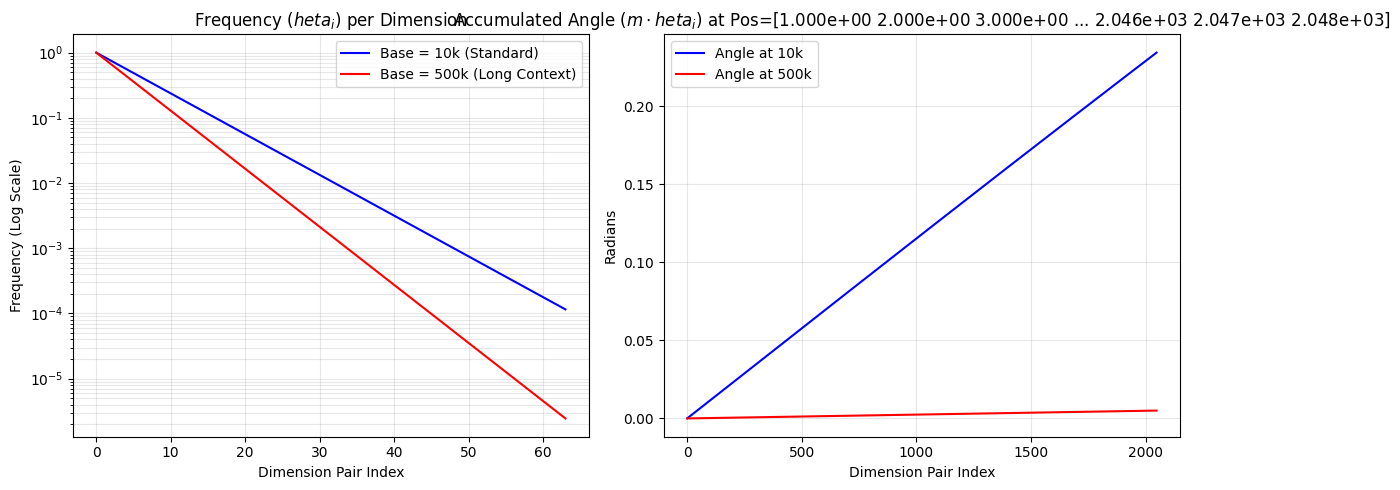

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_freq_and_angle():
    d_model = 128
    indices = np.arange(0, d_model // 2)
    pos = np.linspace(1, 2048, 2048) # 有2048token

    # 计算不同 Base 下的频率 theta
    freq_10k = 1.0 / (10000 ** (2 * indices / d_model)) # shape (64,), numpy
    freq_500k = 1.0 / (500000 ** (2 * indices / d_model))

    plt.figure(figsize=(12, 5))

    # 左图：频率分布
    plt.subplot(1, 2, 1)
    plt.plot(indices, freq_10k, label='Base = 10k (Standard)', color='blue')
    plt.plot(indices, freq_500k, label='Base = 500k (Long Context)', color='red')
    plt.yscale('log')
    plt.title("Frequency ($\theta_i$) per Dimension")
    plt.xlabel("Dimension Pair Index")
    plt.ylabel("Frequency (Log Scale)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.3)

    # 右图：在 Pos=2048 处的累积角度
    plt.subplot(1, 2, 2)
    plt.plot(pos, np.sin(pos * freq_10k[63]), label='Angle at 10k', color='blue')
    plt.plot(pos, np.sin(pos * freq_500k[63]), label='Angle at 500k', color='red')
    # plt.axhline(y=2*np.pi, color='black', linestyle='--', label='2$\pi$ (One Full Circle)')
    plt.title(f"Accumulated Angle ($m \cdot \theta_i$) at Pos={pos}")
    plt.xlabel("Dimension Pair Index")
    plt.ylabel("Radians")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_freq_and_angle()

In [ ]:
print(2%2)

0


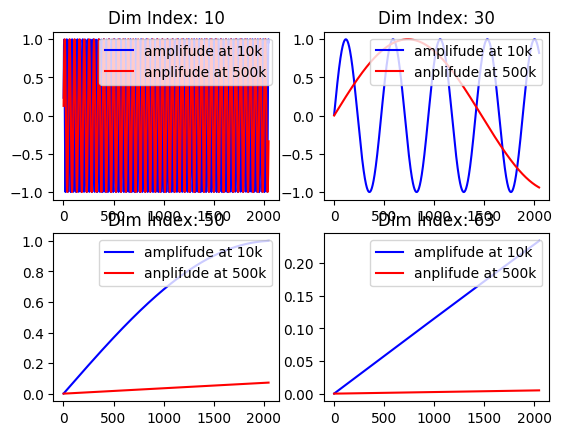

In [ ]:
fig, ax = plt.subplots(2,2,)
d_model = 128
indices = np.arange(0, d_model // 2)
pos = np.linspace(1, 2048, 2048) # 有2048token

freq_10k = 1.0 / (10000 ** (2 * indices / d_model)) # shape (64,), numpy
freq_500k = 1.0 / (500000 ** (2 * indices / d_model))

for i, spos in enumerate([10, 30, 50, 63]):
  # 计算行列索引
  row = i // 2
  col = i % 2
  currentax = ax[row,col]
  currentax.plot(pos, np.sin(pos * freq_10k[spos]), label='amplifude at 10k', color='blue')
  currentax.plot(pos, np.sin(pos * freq_500k[spos]), label='anplifude at 500k', color='red')
  currentax.set_title(f"Dim Index: {spos}")
  currentax.legend(loc='upper right')

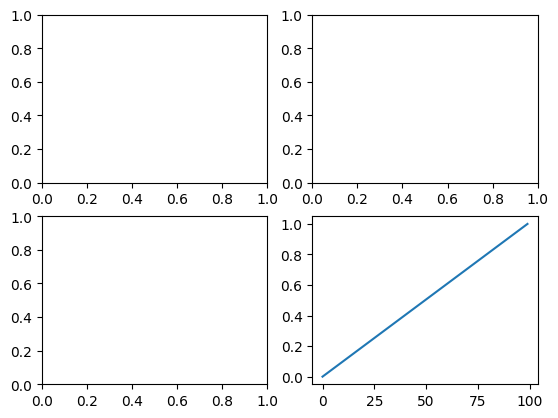

In [ ]:
fig, ax = plt.subplots(2,2,)
ax[1,1].plot(np.linspace(0,1,100))